In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import shap

# SHAP

SHAP stands for SHapley Additive exPlanations.
It’s a unified framework for explaining the predictions of machine learning models by assigning each feature a contribution value.

The concept is based on Shapley values from cooperative game theory, where the “game” is the model’s prediction, and the “players” are the input features.

## The Goal

Given a model $f(x)$ and an input $x$, SHAP decomposes the prediction into a sum of feature contributions:

$$
f(x) = E[f(x)] + \sum\limits_{i} \phi_i
$$

where:

$E[f(x)]$ is the expected (average) model output — the baseline prediction

$\phi_i$ is the SHAP value for feature $i$, representing how much that feature contributes to the deviation from the baseline

Thus, SHAP values add up exactly to the difference between the model’s output and the average prediction.

## How SHAP Works (Conceptually)

Model as a Game: The model’s prediction is seen as the outcome of a game. Each feature (or pixel, word, etc.) is a “player” contributing to the result.

Marginal Contribution: SHAP measures how much each feature changes the prediction on average, across all possible subsets of other features.
This ensures that each feature’s contribution is evaluated in every possible context.

Additivity and Fairness: The Shapley framework guarantees:

- Additivity: the SHAP values sum to the difference between actual and average predictions
- Consistency: if a model changes so that a feature’s contribution increases, its SHAP value will not decrease

In [2]:
tokenizer = AutoTokenizer.from_pretrained("gpt2", use_fast=True)
model = AutoModelForCausalLM.from_pretrained("gpt2")

In [3]:
# set model decoder to true
model.config.is_decoder = True
# set text-generation params under task_specific_params
model.config.task_specific_params["text-generation"] = {
    "do_sample": True,
    "max_length": 50,
    "temperature": 0.7,
    "top_k": 50,
    "no_repeat_ngram_size": 2,
}

In [5]:
s = ["Yesterday I knew a very nice girl. She works as a"]

In [6]:
explainer = shap.Explainer(model, tokenizer)
shap_values = explainer(s)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [7]:
shap.plots.text(shap_values)

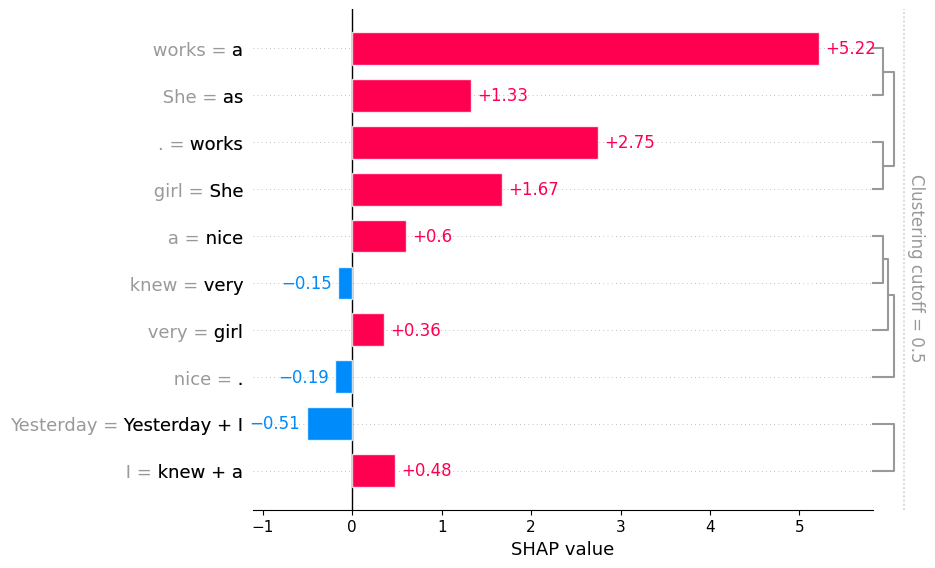

In [8]:
shap.plots.bar(shap_values[0, :, "waitress"])

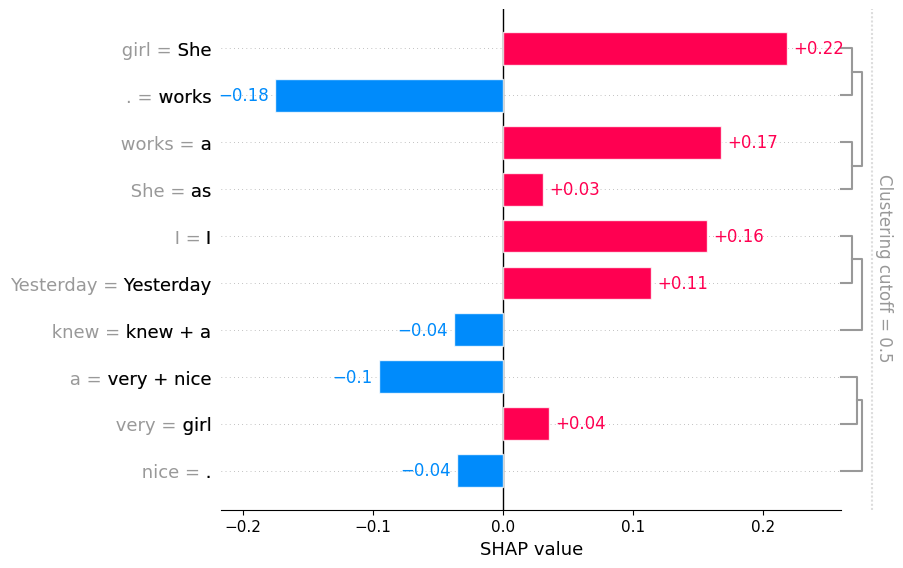

In [9]:
shap.plots.bar(shap_values[0, :, "restaurant"])

## Forcing model

In [10]:
teacher_forcing_model = shap.models.TeacherForcing(model, tokenizer)

In [11]:
x = [
    "Yesterday I knew a very nice girl. She works as a",
    "Yesterday I knew a very nice guy. He works as a",
]

y = [
    "teacher in a university",
    "teacher in a university",
]

In [12]:
teacher_forcing_model = shap.models.TeacherForcing(model, tokenizer)
masker = shap.maskers.Text(tokenizer, mask_token="...", collapse_mask_token=True)

In [13]:
explainer = shap.Explainer(teacher_forcing_model, masker)

In [14]:
shap_values = explainer(x, y)

In [15]:
shap.plots.text(shap_values)

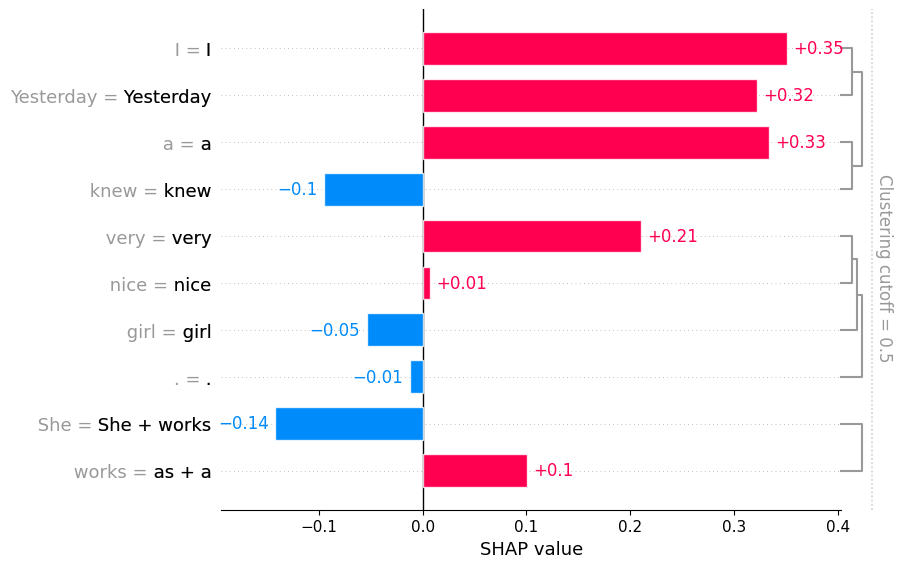

In [20]:
shap.plots.bar(shap_values[0, :, "university"])

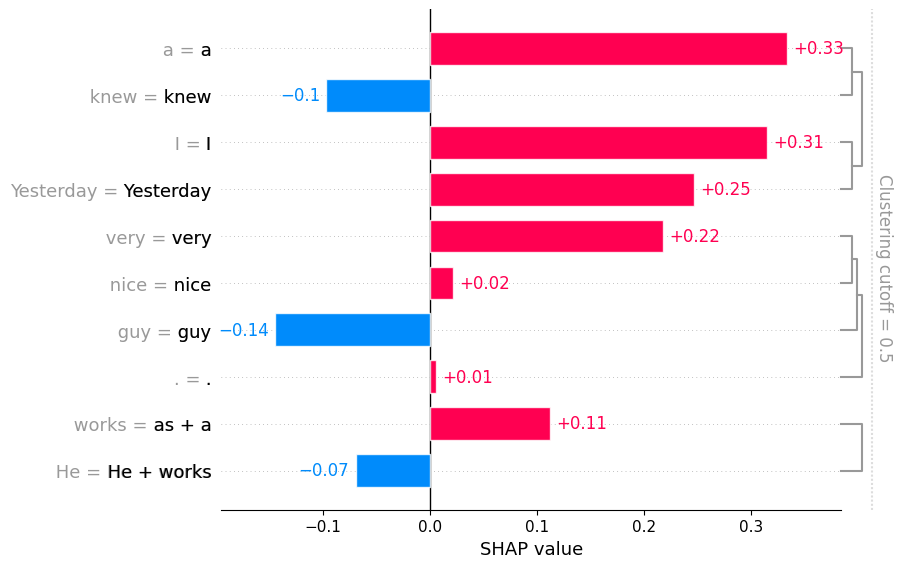

In [21]:
shap.plots.bar(shap_values[1, :, "university"])